In [1]:
import pandas as pd

import os
import sys

sys.path.append(os.path.abspath("../src"))
from harmonization import (
    harmonize_automated_classification,
    harmonize_manual_classification,
)
from visualization import (
    compute_metrics_single_method,
    plot_metrics_single_method,
    plot_metrics_all_methods,
    compute_classification_count,
    compute_upsetplot_data,
    plot_classification_counts,
    plot_upsetplots_automated,
    plot_upsetplot_manual,
    
)



In [2]:
classified_drug_library_data_path = "../data/drug_library/validation_data_classified_all_3_methods.csv"

harmonized_automated = harmonize_automated_classification(classified_drug_library_data_path)
harmonized_manual = harmonize_manual_classification(classified_drug_library_data_path)


In [3]:
harmonized_automated

,FEATURE_ID,SOURCE,DEEPSEEK_RAG,GPT_NO_RAG,GPT_RAG,SEARCH_GPT
0,0,PUBMED,[MEDICAL],[MEDICAL],[MEDICAL],[INFO]
1,1,PUBMED,[MEDICAL],[MEDICAL],[MEDICAL],[MEDICAL]
2,2,PUBMED,[MEDICAL],[MEDICAL],[MEDICAL],[INFO]
3,3,PUBMED,[MEDICAL],[MEDICAL],[MEDICAL],[INFO]
4,4,WIKIPEDIA,[MEDICAL],[MEDICAL],[MEDICAL],[MEDICAL]
...,...,...,...,...,...,...
4948,4948,WIKIPEDIA,[MEDICAL],[MEDICAL],[MEDICAL],[INFO]
4949,4949,WIKIPEDIA,"[FOOD, ENDOGENOUS]","[ENDOGENOUS, FOOD]","[ENDOGENOUS, FOOD]","[ENDOGENOUS, FOOD]"
4950,4950,WIKIPEDIA,"[INDUSTRIAL, MEDICAL]",[INDUSTRIAL],[INDUSTRIAL],[INDUSTRIAL]
4951,4951,WIKIPEDIA,"[MEDICAL, ENDOGENOUS]",[INFO],[ENDOGENOUS],[INFO]


In [4]:
def bits_to_classification(bits):
    categories = ["MEDICAL", "FOOD", "INDUSTRIAL", "PERSONAL CARE", "ENDOGENOUS", "INFO"]
    classification = [categories[i] for i in range(len(categories)) if bits[i] == "1"]
    return classification

def harmonize_bit_df(bit_df_path, input_column, output_column):
    bit_df = pd.read_csv(bit_df_path, dtype={input_column: str})
    bit_df_harmonized = bit_df.copy()
    bit_df_harmonized[output_column] = bit_df_harmonized[input_column].apply(bits_to_classification)
    bit_df_harmonized.drop(columns=[input_column], inplace=True)
    return bit_df_harmonized

In [20]:
industrial_loose_path = "../data/drug_library/multiple_prompts/industrial_loose_bits.csv"
industrial_strict_path = "../data/drug_library/multiple_prompts/industrial_strict_bits.csv"
industrial_strict_medical_loose_path = "../data/drug_library/multiple_prompts/industrial_strict_medical_loose_bits.csv"
no_description_path = "../data/drug_library/multiple_prompts/no_description_bits.csv"

industrial_loose_df = harmonize_bit_df(industrial_loose_path, "INDUSTRIAL_LOOSE_BITS", "INDUSTRIAL_LOOSE")
industrial_strict_df = harmonize_bit_df(industrial_strict_path, "INDUSTRIAL_STRICT_BITS", "INDUSTRIAL_STRICT")
industrial_strict_medical_loose_df = harmonize_bit_df(industrial_strict_medical_loose_path, "INDUSTRIAL_STRICT_MEDICAL_LOOSE_BITS", "INDUSTRIAL_STRICT_MEDICAL_LOOSE")
no_description_df = harmonize_bit_df(no_description_path, "NO_DESCRIPTION_BITS", "NO_DESCRIPTION")

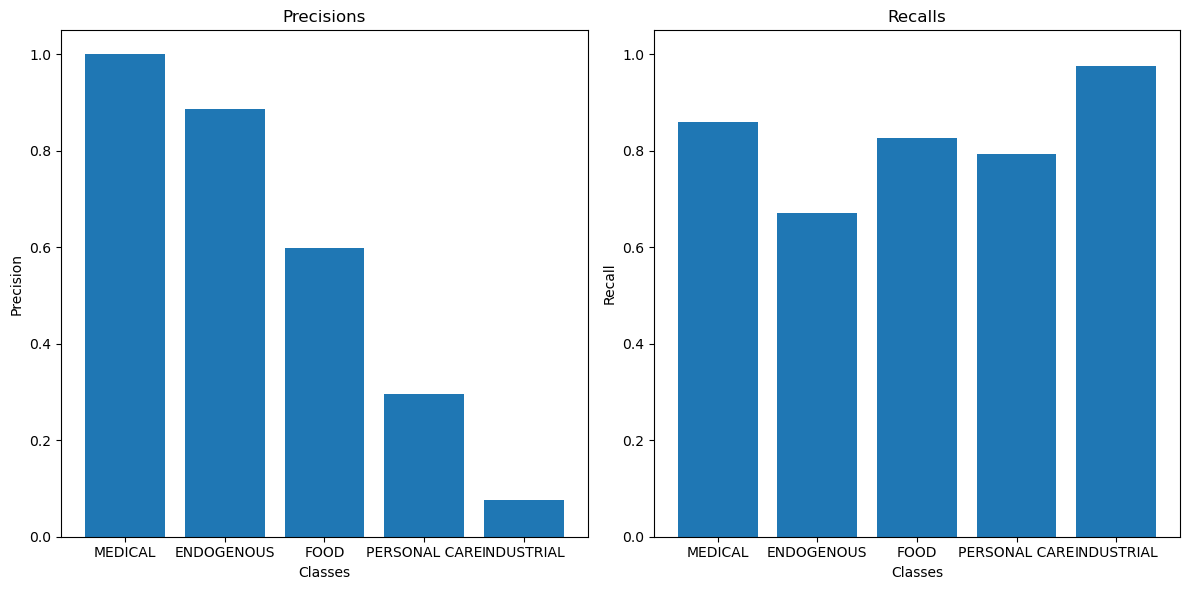

In [21]:
industrial_loose_metrics = compute_metrics_single_method(industrial_loose_df, harmonized_manual, "INDUSTRIAL_LOOSE")
plot_metrics_single_method(industrial_loose_metrics)

In [18]:
def pr_rec_to_f1(pr_rec_dict):
    precisions = pr_rec_dict["precisions"]
    recalls = pr_rec_dict["recalls"]
    f1_dict = {}
    for key in precisions.keys():
        curr_precision = precisions[key]
        curr_recall = recalls[key]
        f1 = (2 * curr_precision * curr_recall) / (curr_precision + curr_recall)
        f1_dict[key] = f1
    return f1_dict
    

In [22]:
industrial_loose_f1 = pr_rec_to_f1(industrial_loose_metrics)
industrial_loose_metrics_updated = industrial_loose_metrics.copy()
industrial_loose_metrics_updated["f1"] = industrial_loose_f1

In [26]:
pd.DataFrame(industrial_loose_metrics_updated).T.to_csv("../data/drug_library/multiple_prompts_results/industrial_loose_prompt_results.csv")

action items

- run 50 medical compounds 100x
- run the 100x repetition again with prompting to add explanation before clear_output
- run the multiple prompts analysis again with a prompt with no category explanations
- run the stricter industrial prompt again, but also loosen the medical definition to something like "Note that MEDICAL refers to compounds used as medications in humans or animals"

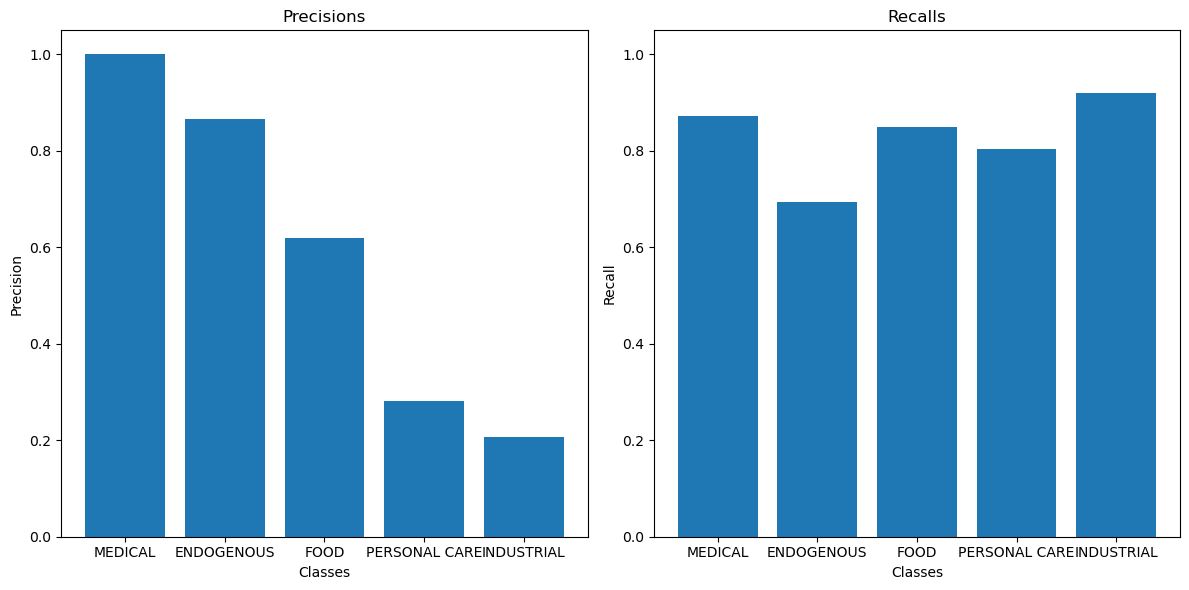

In [27]:
industrial_strict_metrics = compute_metrics_single_method(industrial_strict_df, harmonized_manual, "INDUSTRIAL_STRICT")
plot_metrics_single_method(industrial_strict_metrics)



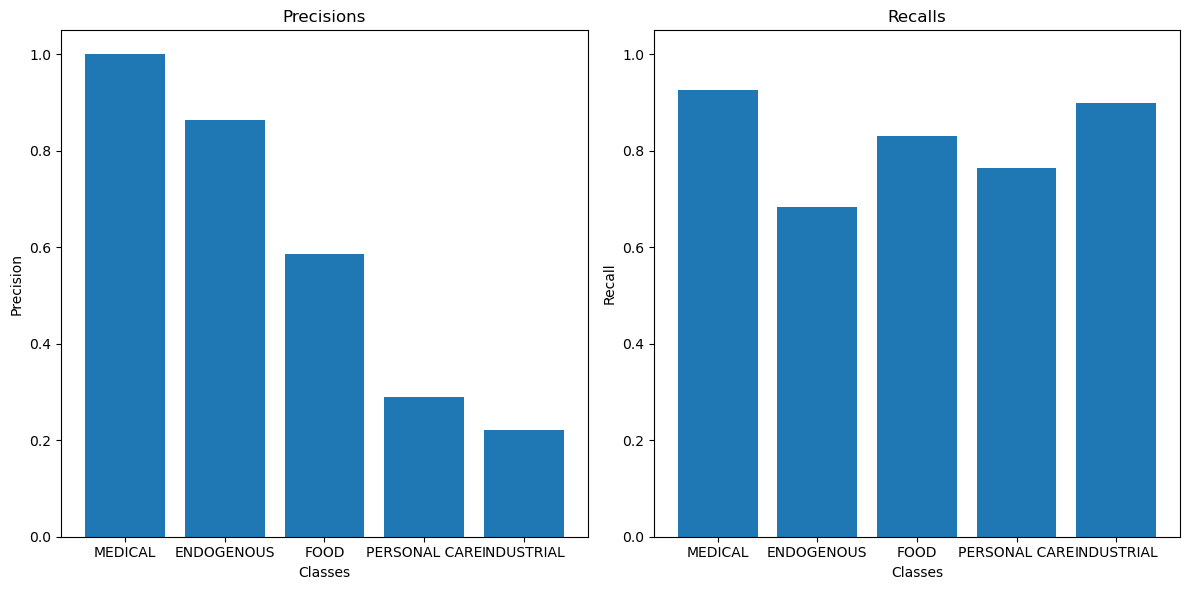

In [31]:
industrial_strict_medical_loose_metrics = compute_metrics_single_method(industrial_strict_medical_loose_df, harmonized_manual, "INDUSTRIAL_STRICT_MEDICAL_LOOSE")
plot_metrics_single_method(industrial_strict_medical_loose_metrics)

In [32]:
industrial_strict_medical_loose_f1 = pr_rec_to_f1(industrial_strict_medical_loose_metrics)
industrial_strict_medical_loose_metrics_updated = industrial_strict_medical_loose_metrics.copy()
industrial_strict_medical_loose_metrics_updated["f1"] = industrial_strict_medical_loose_f1

In [33]:
pd.DataFrame(industrial_strict_medical_loose_metrics_updated).T.to_csv("../data/drug_library/multiple_prompts_results/industrial_strict_medical_loose_prompt_results.csv")


In [11]:
drug_library_text = pd.read_csv(classified_drug_library_data_path)
drug_library_text["FEATURE_ID"] = drug_library_text.index
drug_library_text = drug_library_text[["FEATURE_ID", 
    "name_used", 
    "text"]].rename(columns={
    "name_used": "NAME",
    "text": "TEXT"})

In [15]:
industrial_strict_medical_loose_df_with_text = industrial_strict_medical_loose_df.merge(
    drug_library_text, on="FEATURE_ID", how="left"
)

In [17]:
industrial_strict_medical_loose_df_with_text.to_csv("../data/drug_library/multiple_prompts/industrial_strict_medical_loose_with_text.csv", index=False)

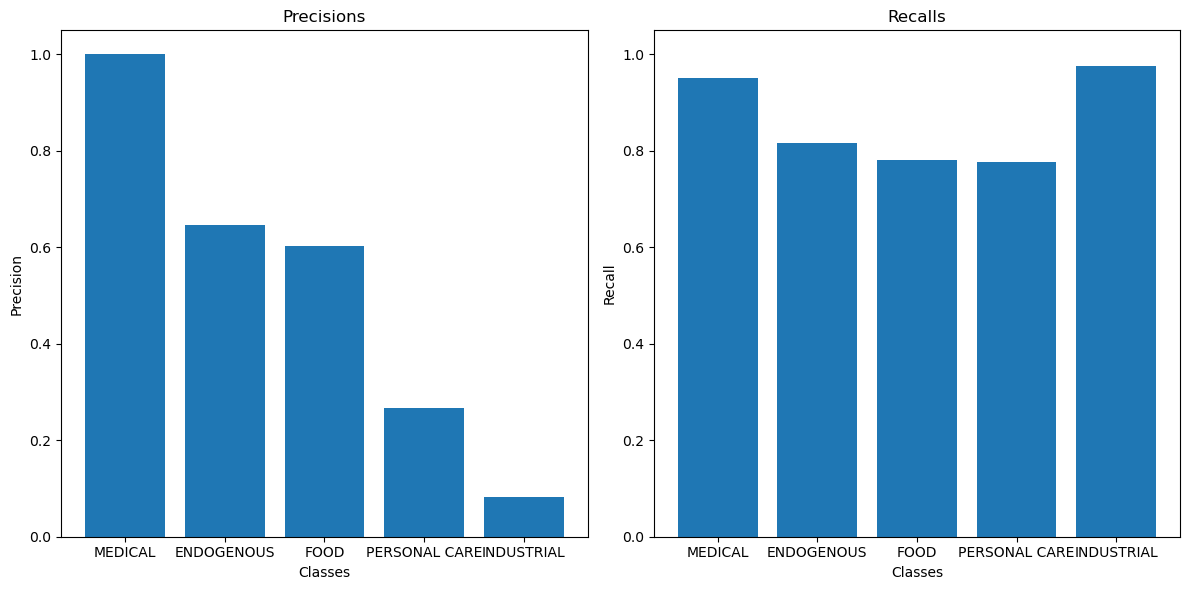

In [35]:
no_description_metrics = compute_metrics_single_method(no_description_df, harmonized_manual, "NO_DESCRIPTION")
plot_metrics_single_method(no_description_metrics)

In [37]:
no_description_metrics_f1 = pr_rec_to_f1(no_description_metrics)
no_description_metrics_updated = no_description_metrics.copy()
no_description_metrics_updated["f1"] = no_description_metrics_f1

In [39]:
pd.DataFrame(no_description_metrics_updated).T.to_csv("../data/drug_library/multiple_prompts_results/no_description_prompt_results.csv")